In [2]:
import numpy as np

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [21]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)


In [36]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

In [27]:
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)
        
        x[idx] = float(tmp_val) - h
        fxh2 = f(x)
        grad[idx] = (fxh1 - fxh2) / (2 * h)
        
        x[idx] = tmp_val
        it.iternext()
    return grad

In [38]:
def sigmoid_grad(x):
    return (1.0 - sigmoid(x)) * sigmoid(x)

In [39]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)
        
    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        return y

    def loss(self, x, t):
        y = self.predict(x)
        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        
        accuracy = np.sum(y==t)/float(x.shape[0])
        return accuracy
    
    def numerical_gradient(self, x, t):
        loss_W = lambda w: self.loss(x, t)
        
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        
        return grads
    
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}
        
        batch_num = x.shape[0]
        
        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)
        
        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads

In [40]:
net = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)

In [41]:
from mnist import load_mnist
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

In [68]:
train_loss_list = []

iters_num = 100000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

In [69]:
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

In [70]:
iters_num

100000

In [71]:
for i in range(iters_num):
    print('iter: ',i)
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    grad = network.gradient(x_batch, t_batch)
    
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

iter:  0
iter:  1
iter:  2
iter:  3
iter:  4
iter:  5
iter:  6
iter:  7
iter:  8
iter:  9
iter:  10
iter:  11
iter:  12
iter:  13
iter:  14
iter:  15
iter:  16
iter:  17
iter:  18
iter:  19
iter:  20
iter:  21
iter:  22
iter:  23
iter:  24
iter:  25
iter:  26
iter:  27
iter:  28
iter:  29
iter:  30
iter:  31
iter:  32
iter:  33
iter:  34
iter:  35
iter:  36
iter:  37
iter:  38
iter:  39
iter:  40
iter:  41
iter:  42
iter:  43
iter:  44
iter:  45
iter:  46
iter:  47
iter:  48
iter:  49
iter:  50
iter:  51
iter:  52
iter:  53
iter:  54
iter:  55
iter:  56
iter:  57
iter:  58
iter:  59
iter:  60
iter:  61
iter:  62
iter:  63
iter:  64
iter:  65
iter:  66
iter:  67
iter:  68
iter:  69
iter:  70
iter:  71
iter:  72
iter:  73
iter:  74
iter:  75
iter:  76
iter:  77
iter:  78
iter:  79
iter:  80
iter:  81
iter:  82
iter:  83
iter:  84
iter:  85
iter:  86
iter:  87
iter:  88
iter:  89
iter:  90
iter:  91
iter:  92
iter:  93
iter:  94
iter:  95
iter:  96
iter:  97
iter:  98
iter:  99
iter:  100

Text(0.5, 1.0, 'loss per iteration')

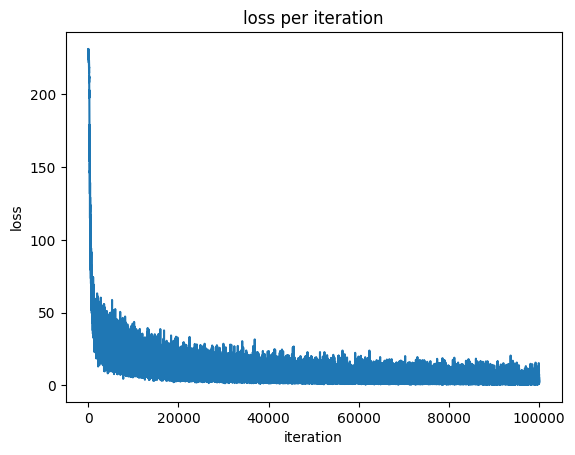

In [72]:
import matplotlib.pyplot as plt

x = np.arange(len(train_loss_list))
plt.plot(x, train_loss_list)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title("loss per iteration")

evaluation

In [73]:
train_loss_list = []
train_acc_list = []
test_acc_list = []

In [74]:
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

In [75]:
iter_per_epoch = max(train_size / batch_size, 1)

In [76]:
for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    grad = network.gradient(x_batch, t_batch)
    
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    if i%iter_per_epoch ==0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " +str(train_acc) + ", " +str(test_acc))


train acc, test acc | 0.10218333333333333, 0.101
train acc, test acc | 0.7906166666666666, 0.797
train acc, test acc | 0.8776833333333334, 0.8819
train acc, test acc | 0.898, 0.9006
train acc, test acc | 0.9095666666666666, 0.9107
train acc, test acc | 0.9148166666666666, 0.9171
train acc, test acc | 0.9197833333333333, 0.9217
train acc, test acc | 0.9231, 0.9232
train acc, test acc | 0.9274333333333333, 0.9272
train acc, test acc | 0.93065, 0.9313
train acc, test acc | 0.9325, 0.9323
train acc, test acc | 0.9366, 0.9354
train acc, test acc | 0.9389166666666666, 0.9374
train acc, test acc | 0.9394666666666667, 0.9392
train acc, test acc | 0.9424, 0.9416
train acc, test acc | 0.9446166666666667, 0.9435
train acc, test acc | 0.9464333333333333, 0.9439
train acc, test acc | 0.9474, 0.9458
train acc, test acc | 0.9485666666666667, 0.9469
train acc, test acc | 0.9506166666666667, 0.9489
train acc, test acc | 0.9516333333333333, 0.949
train acc, test acc | 0.9525666666666667, 0.9497
train ac

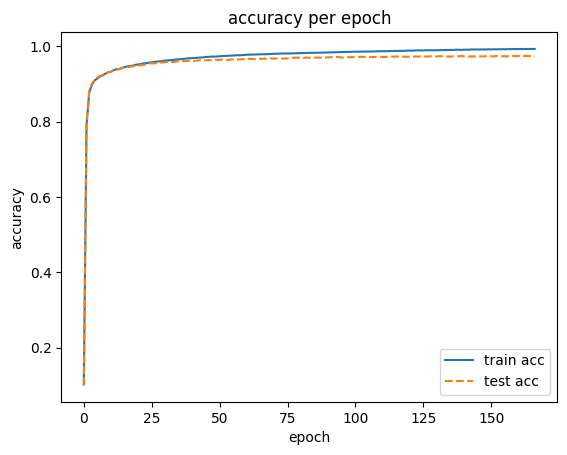

In [77]:
epoch = np.arange(len(train_acc_list))
plt.plot(epoch, train_acc_list, label='train acc')
plt.plot(epoch, test_acc_list, label='test acc', linestyle='--')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title("accuracy per epoch")
plt.legend()